# Log Anomaly Detection (HDFS Dataset): Isolation Forest Pipeline


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================

import subprocess, sys

def install_packages(packages):
    for pkg in packages:
        print(f"Installing: {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            print(f"  WARNING: may have failed — {result.stderr[:200]}")
        else:
            print("  OK")

install_packages([
    "pandas", "numpy", "scikit-learn",
    "matplotlib", "seaborn",
    "sentence-transformers",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: sentence-transformers
  OK

All packages ready.


C:\Users\Abhishek Mulay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Dataset              : HDFS
  Embedding model      : all-MiniLM-L6-v2
  IF n_estimators      : 200
  IF max_samples       : auto
  IF max_features      : 1.0
  IF contamination     : auto
  Train ratio          : 0.6
  Val ratio            : 0.2
  Test normals         : remaining 20% of normals
  Test anomalies       : ALL available (no cap)
  F-beta               : 0.5
Loading dataset: HDFS
  Loading HDFS block traces ...
    Block traces: 575061, Templates: 29
    After sampling  : 10303 blocks (10000 normal, 303 anomalous)

  Total samples     : 10303
  Normal            : 10000  (97.1%)
  Anomalous         : 303  (2.9%)

  Sample log_text:
    HDFS Block Trace | Receiving blocksrc:dest: -> BLOCK* NameSystemallocateBlock: -> PacketResponderfor blockterminating -> Received blockof sizefrom -> BLOCK* NameSystemaddStoredBlock: blockMap updated:is added tosize -> BLOCK* NameSystemdelete:is added to invalidSet of -> Deleting blockfile
Creating train / validation / test splits ...

  Tr

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3684.64it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embedding dimension : 384

Encoding train set (6000 samples) ...


Batches: 100%|██████████| 94/94 [02:24<00:00,  1.54s/it]


Encoding validation set (2000 samples) ...


Batches: 100%|██████████| 32/32 [00:44<00:00,  1.40s/it]


Encoding test set (2303 samples) ...


Batches: 100%|██████████| 36/36 [00:53<00:00,  1.50s/it]



  Train embeddings  : (6000, 384)
  Val embeddings    : (2000, 384)
  Test embeddings   : (2303, 384)
Isolation Forest configuration:
  n_estimators  : 200
  max_samples   : auto
  max_features  : 1.0
  contamination : auto
  n_jobs        : -1  (all available cores)
Fitting Isolation Forest on 6000 normal embeddings ...
Training complete.
  Effective max_samples per tree : 256
  Total trees fitted             : 200
  Feature dimension              : 384
Computing validation-set anomaly scores ...
  Val score stats (normal logs only):
    Min    : 0.3458
    Median : 0.4655
    Max    : 0.7165

  Threshold selection via F-beta (beta=0.5) on validation PR curve:
    Best threshold       : 0.5670
    At threshold         : Precision=1.000  Recall=1.000  F0.5=1.000
    Pseudo-anomaly count : 142  (top 7% of 2000 val normals)
Scoring test set ...

  EVALUATION  --  Isolation Forest  [HDFS]
  Test set size          : 2303
    Normal   (neg)       : 2000  (86.8%)
    Anomalous (pos)      : 

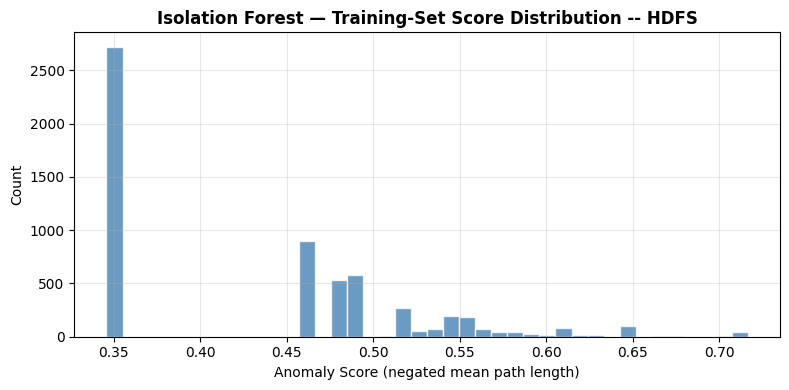

  Saved: hdfs_if_train_score_dist.png


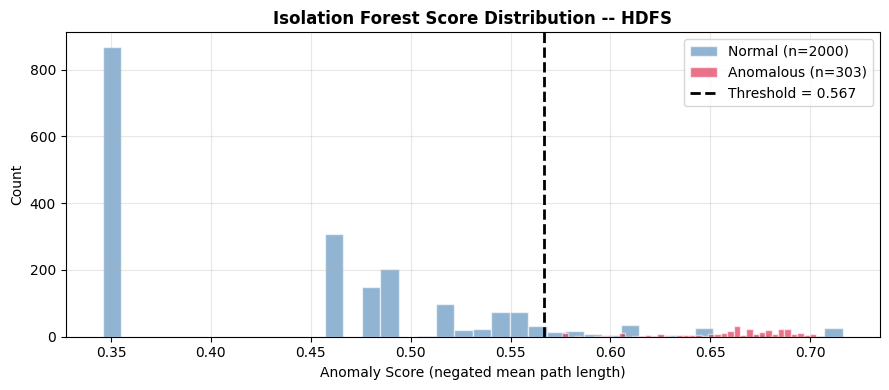

  Saved: hdfs_if_score_dist.png


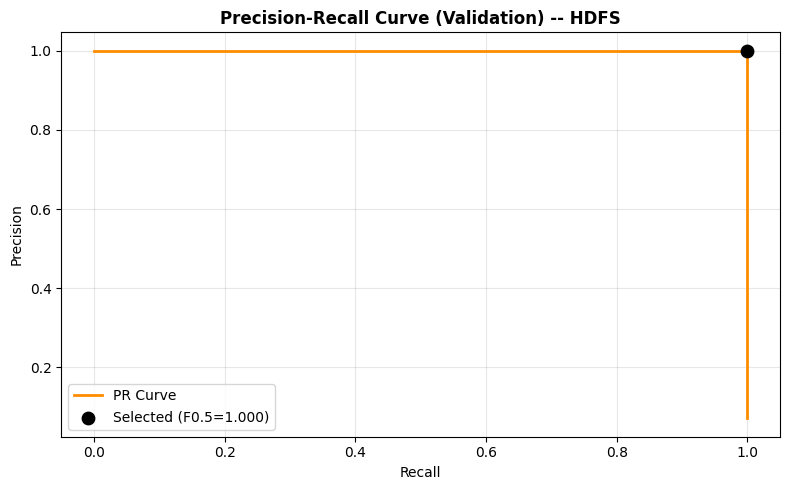

  Saved: hdfs_if_pr_curve.png


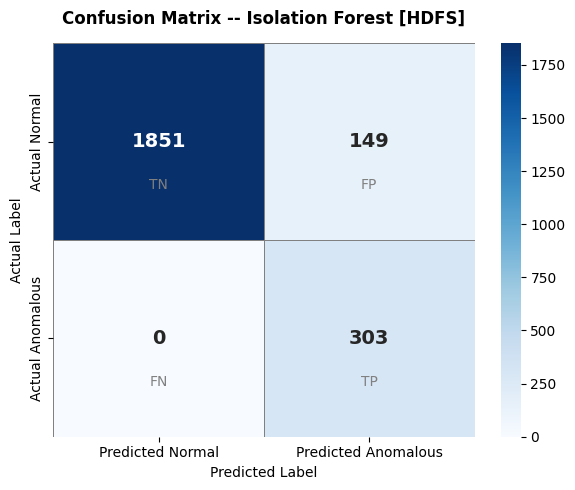

  Saved: hdfs_if_confusion_matrix.png


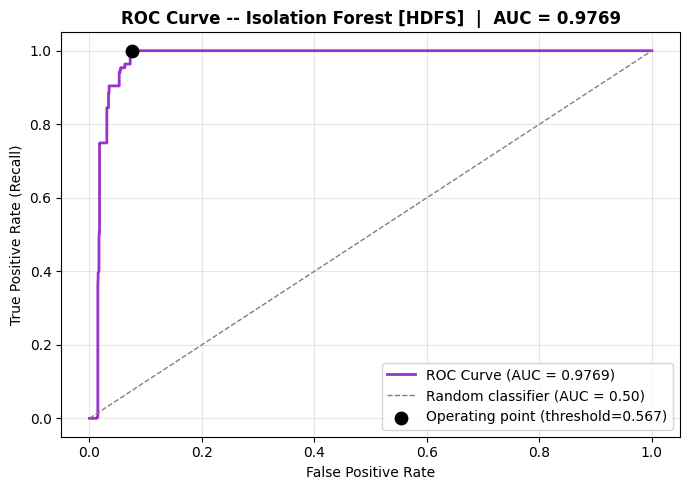

  Saved: hdfs_if_roc_curve.png


In [2]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================

import json, os, re, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Dataset selection ─────────────────────────────────────────────────────────
DATASET = "HDFS"

# ── Dataset-specific configurations ──────────────────────────────────────────

DATASET_CONFIGS = {
    "BGL": {
        "structured_log_path": "../../Datasets/BGL/Sample/BGL_2k.log_structured.csv",
        "templates_path":      "../../Datasets/BGL/Sample/BGL_2k.log_templates.csv",
        # Schema
        "label_col":     "Label",
        "normal_value":  "-",           # '-' = Normal in BGL
        "event_id_col":  "EventId",
        "component_col": "Component",
        "level_col":     "Level",
        "content_col":   "Content",
        "template_col":  "EventTemplate",
        # Sampling: BGL-2k is small (~2k rows), no caps needed
        "normal_sample_cap":  None,
        "anomaly_type_col":   None,
        "anomaly_n_per_type": None,
    },
    "HDFS": {
        "traces_path":    "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/Event_traces.csv",
        "templates_path": "../../Datasets/HDFS/Full_HDFS_v1/preprocessed/HDFS.log_templates.csv",
        # Schema
        "label_col":    "Label",
        "normal_value": "Success",      # 'Success' = Normal, 'Fail' = Anomalous
        "features_col": "Features",     # column holding [E5,E22,...] sequence
        # Sampling caps — evidence-based from full-dataset fingerprint analysis:
        #   558,223 normal blocks have only 365 unique event-sequence fingerprints.
        #   Top 15 fingerprints cover 90%, top 55 cover 99% of all normal blocks.
        #   A 10,000-normal random sample captures all high-frequency patterns,
        #   cutting train size 56x (334,933 -> 6,000) with negligible diversity loss.
        #   Anomaly stratification: 20 samples/type across all 26 types = 303 total,
        #   giving full anomaly-type coverage for reliable evaluation and RAG retrieval.
        "normal_sample_cap":  10000,    # None = use all; 10k covers 99%+ of distribution
        "anomaly_type_col":   "Type",   # column used to stratify anomaly sampling
        "anomaly_n_per_type": 20,       # samples per anomaly type (all 26 types -> ~303 total)
    },
}

# ── Embedding model ───────────────────────────────────────────────────────────
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
EMBED_DIM        = 384   # confirmed after model load

# ── Isolation Forest hyper-parameters ────────────────────────────────────────
IF_N_ESTIMATORS   = 200    # number of isolation trees
IF_MAX_SAMPLES    = "auto" # samples per tree: "auto" = min(256, n_train)
IF_MAX_FEATURES   = 1.0    # fraction of features per tree
IF_CONTAMINATION  = "auto" # no prior on anomaly rate — threshold calibrated on val

# ── Split ratios ─────────────────────────────────────────────────────
TRAIN_RATIO = 0.60   # fraction of normal samples for IF training
VAL_RATIO   = 0.20   # fraction of normal samples for threshold calibration
TEST_NORMAL_CAP  = 215   # max normal samples in test set
TEST_ANOMALY_CAP = 15    # max anomalous samples in test set

# ── Threshold calibration ─────────────────────────────────────────────────────
PSEUDO_ANOMALY_PERCENTILE = 93   # bottom 7% of val scores = pseudo-anomalies
FBETA = 0.5                      # beta < 1 weights precision over recall

print(f"  Dataset              : {DATASET}")
print(f"  Embedding model      : {EMBED_MODEL_NAME}")
print(f"  IF n_estimators      : {IF_N_ESTIMATORS}")
print(f"  IF max_samples       : {IF_MAX_SAMPLES}")
print(f"  IF max_features      : {IF_MAX_FEATURES}")
print(f"  IF contamination     : {IF_CONTAMINATION}")
print(f"  Train ratio          : {TRAIN_RATIO}")
print(f"  Val ratio            : {VAL_RATIO}")
print(f"  Test normals         : remaining {1.0 - TRAIN_RATIO - VAL_RATIO:.0%} of normals")
print(f"  Test anomalies       : ALL available (no cap)")
print(f"  F-beta               : {FBETA}")


# =============================================================================
# GENERIC DATA LOADING
#
# Output contract (identical for every dataset):
#   log_text     (str)  — enriched text fed to the sentence transformer
#   is_normal    (bool) — True if the sample is labelled Normal
#   binary_label (int)  — 0 = Normal, 1 = Anomalous
#
# BGL  loader : line-level;  one row = one log line
# HDFS loader : block-level; one row = one block trace (event sequence)
# =============================================================================


# ── Dataset-size sampling (applied before log_text construction) ──────────────

def _apply_sampling(df, config, random_seed=42):
    """Apply per-dataset sampling caps to keep dataset size manageable.

    Called inside each loader BEFORE building log_text, so the expensive
    DataFrame.apply(...) step only runs on the sampled rows — not on the
    full 575k HDFS blocks.

    Normal blocks   : random sample up to config["normal_sample_cap"].
    Anomalous blocks: stratified by config["anomaly_type_col"], taking up to
                      config["anomaly_n_per_type"] samples per category.
                      This ensures all anomaly types are represented even at
                      small sample sizes (all 26 HDFS types with just 20/type).
                      Falls back to a flat random cap via "anomaly_sample_cap"
                      when stratification fields are absent.

    For datasets without caps (e.g. BGL-2k), all values are None and this
    function returns df unchanged.

    Args:
        df          : DataFrame with is_normal (bool) already set.
        config      : Per-dataset dict from DATASET_CONFIGS.
        random_seed : For reproducible sampling.

    Returns:
        Sampled (or original) DataFrame with reset index.
    """
    normal_cap    = config.get("normal_sample_cap")
    anom_type_col = config.get("anomaly_type_col")
    n_per_type    = config.get("anomaly_n_per_type")
    anom_cap      = config.get("anomaly_sample_cap")

    df_n = df[df["is_normal"]].copy()
    df_a = df[~df["is_normal"]].copy()

    if normal_cap is not None and len(df_n) > normal_cap:
        df_n = df_n.sample(n=normal_cap, random_state=random_seed)

    if anom_type_col and n_per_type:
        parts = [
            grp.sample(n=min(n_per_type, len(grp)), random_state=random_seed)
            for _, grp in df_a.groupby(anom_type_col)
            if len(grp) > 0
        ]
        df_a = pd.concat(parts) if parts else df_a
    elif anom_cap is not None and len(df_a) > anom_cap:
        df_a = df_a.sample(n=anom_cap, random_state=random_seed)

    return pd.concat([df_n, df_a], ignore_index=True)


# ── BGL helpers ───────────────────────────────────────────────────────────────

def build_bgl_log_text(row, config):
    """Construct enriched text for a single BGL log line.

    Format: [COMPONENT] [LEVEL] <content> | Template: <drain_template>
    Combining concrete content with the abstract template improves
    embedding quality by exposing both signal types to the model.
    """
    component = str(row.get(config["component_col"], "")).strip()
    level     = str(row.get(config["level_col"],     "")).strip()
    content   = str(row.get(config["content_col"],   "")).strip()
    template  = str(row.get(config["template_col"],  "")).strip()
    return f"[{component}] [{level}] {content} | Template: {template}"


def load_bgl_data(config):
    """Load BGL structured log CSV, merge templates, build log_text."""
    print("  Loading BGL structured log ...")
    df_logs      = pd.read_csv(config["structured_log_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Rows: {len(df_logs)}, Templates: {len(df_templates)}")

    df = df_logs.merge(
        df_templates, on=config["event_id_col"],
        how="left", suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df = _apply_sampling(df, config)          # no-op for BGL (caps are None)
    df["log_text"]     = df.apply(
        lambda row: build_bgl_log_text(row, config), axis=1
    )
    return df


# ── HDFS helpers ──────────────────────────────────────────────────────────────

def _clean_template(text):
    """Remove Drain wildcards [*] and collapse whitespace."""
    cleaned = re.sub(r'\[\*\]', '', text)
    return re.sub(r'\s+', ' ', cleaned).strip()


def build_hdfs_log_text(row, config, template_lookup):
    """Construct enriched text for an HDFS block trace.

    Parses the ordered event-ID sequence from the Features column (e.g.
    [E5,E22,E5,E11,...]), resolves each unique event ID to its Drain
    template, and joins them with ' -> ' to represent the block lifecycle.

    Unique-ordered de-duplication avoids repeating the same template many
    times while preserving the event-ordering signal. Normal blocks produce
    pipeline sentences; anomalous blocks introduce error-event templates
    that give the sentence transformer a distinctive anomaly signal.
    """
    features_str = str(row.get(config["features_col"], "[]"))
    event_ids    = re.findall(r'E\d+', features_str)
    seen, unique_templates = set(), []
    for eid in event_ids:
        if eid not in seen:
            seen.add(eid)
            tmpl = template_lookup.get(eid, eid)
            unique_templates.append(_clean_template(tmpl))
    return "HDFS Block Trace | " + " -> ".join(unique_templates)


def load_hdfs_data(config):
    """Load HDFS Event_traces.csv, build block-level log_text."""
    print("  Loading HDFS block traces ...")
    df_traces    = pd.read_csv(config["traces_path"])
    df_templates = pd.read_csv(config["templates_path"])
    print(f"    Block traces: {len(df_traces)}, Templates: {len(df_templates)}")

    template_lookup = dict(
        zip(df_templates["EventId"], df_templates["EventTemplate"])
    )
    df_traces["is_normal"]    = (
        df_traces[config["label_col"]] == config["normal_value"]
    )
    df_traces["binary_label"] = (~df_traces["is_normal"]).astype(int)

    # Sample BEFORE building log_text — avoids calling apply() on discarded rows
    df_traces = _apply_sampling(df_traces, config)
    n_s = int(df_traces["is_normal"].sum())
    n_a = int((~df_traces["is_normal"]).sum())
    print(f"    After sampling  : {len(df_traces)} blocks "
          f"({n_s} normal, {n_a} anomalous)")

    df_traces["log_text"]     = df_traces.apply(
        lambda row: build_hdfs_log_text(row, config, template_lookup), axis=1
    )
    return df_traces


# ── Public entry point ────────────────────────────────────────────────────────

def load_data(dataset_name, configs):
    """Dispatch to the dataset-specific loader.

    Returns a DataFrame guaranteed to have:
        log_text (str), is_normal (bool), binary_label (int).

    Args:
        dataset_name : "BGL" or "HDFS"
        configs      : DATASET_CONFIGS dict
    """
    if dataset_name not in configs:
        raise ValueError(
            f"Unknown dataset '{dataset_name}'. "
            f"Available: {list(configs.keys())}"
        )
    if dataset_name == "BGL":
        return load_bgl_data(configs[dataset_name])
    elif dataset_name == "HDFS":
        return load_hdfs_data(configs[dataset_name])


# ── Execute ───────────────────────────────────────────────────────────────────

print(f"Loading dataset: {DATASET}")
df = load_data(DATASET, DATASET_CONFIGS)

n_normal    = int(df["is_normal"].sum())
n_anomalous = int((~df["is_normal"]).sum())
print(f"\n  Total samples     : {len(df)}")
print(f"  Normal            : {n_normal}  ({n_normal / len(df) * 100:.1f}%)")
print(f"  Anomalous         : {n_anomalous}  ({n_anomalous / len(df) * 100:.1f}%)")
print(f"\n  Sample log_text:\n    {df['log_text'].iloc[0]}")


# =============================================================================
# GENERIC TRAIN / VALIDATION / TEST SPLIT
#
# Split layout (all proportions of normal logs):
#   Train      : TRAIN_RATIO (0.60)
#   Validation : VAL_RATIO   (0.20)
#   Test       : remaining   (0.20) of normals  +  ALL anomalies
# =============================================================================


def create_splits(df, train_ratio=0.60, val_ratio=0.20, random_seed=42,
                  test_normal_cap=None, test_anomaly_cap=None):
    """Split dataset into train, validation, and test subsets.

    Train and validation contain only normal samples (one-class learning
    requires anomaly-free training and calibration data). Test contains
    the remaining normal samples and anomalous samples, both optionally
    capped via test_normal_cap / test_anomaly_cap.

    Args:
        df           : DataFrame with is_normal (bool) and binary_label (int).
        train_ratio  : Fraction of normals for Isolation Forest training.
        val_ratio    : Fraction of normals for threshold calibration.
        random_seed  : Seed for reproducible shuffling.

    Returns:
        train_df, val_df, test_df
    """
    assert train_ratio + val_ratio <= 1.0, (
        "train_ratio + val_ratio must not exceed 1.0"
    )

    df_normal    = (df[df["is_normal"]]
                    .sample(frac=1, random_state=random_seed)
                    .reset_index(drop=True))
    df_anomalous = df[~df["is_normal"]].reset_index(drop=True)

    n_total = len(df_normal)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)

    train_df    = df_normal.iloc[:n_train].reset_index(drop=True)
    val_df      = df_normal.iloc[n_train: n_train + n_val].reset_index(drop=True)
    test_normal = df_normal.iloc[n_train + n_val:].reset_index(drop=True)

    if test_normal_cap is not None and len(test_normal) > test_normal_cap:
        test_normal   = test_normal.iloc[:test_normal_cap].reset_index(drop=True)
    if test_anomaly_cap is not None and len(df_anomalous) > test_anomaly_cap:
        df_anomalous  = df_anomalous.sample(
            n=test_anomaly_cap, random_state=random_seed
        ).reset_index(drop=True)

    test_df = (
        pd.concat([test_normal, df_anomalous], ignore_index=True)
        .sample(frac=1, random_state=random_seed)
        .reset_index(drop=True)
    )
    return train_df, val_df, test_df


# ── Execute ───────────────────────────────────────────────────────────────────

print("Creating train / validation / test splits ...")
train_df, val_df, test_df = create_splits(
    df, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, random_seed=RANDOM_SEED,
    test_normal_cap=TEST_NORMAL_CAP, test_anomaly_cap=TEST_ANOMALY_CAP,
)

n_test_normal    = int(test_df["is_normal"].sum())
n_test_anomalous = int((~test_df["is_normal"]).sum())

print(f"\n  Train  : {len(train_df):>6}  normal only")
print(f"  Val    : {len(val_df):>6}  normal only  (threshold calibration)")
print(f"  Test   : {len(test_df):>6}  total")
print(f"           {n_test_normal:>6}  normal     ({n_test_normal / len(test_df) * 100:.1f}%)")
print(f"           {n_test_anomalous:>6}  anomalous  ({n_test_anomalous / len(test_df) * 100:.1f}%)")


# =============================================================================
# SENTENCE EMBEDDINGS
#
# all-MiniLM-L6-v2 encodes BGL log-line text and HDFS block-trace text
# into the same 384-dim space. No changes needed here when switching datasets.
# =============================================================================

print(f"Loading sentence transformer '{EMBED_MODEL_NAME}' ...")
embedder  = SentenceTransformer(EMBED_MODEL_NAME)
EMBED_DIM = embedder.get_sentence_embedding_dimension()
print(f"  Embedding dimension : {EMBED_DIM}")

print(f"\nEncoding train set ({len(train_df)} samples) ...")
train_embeddings = embedder.encode(
    train_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"Encoding validation set ({len(val_df)} samples) ...")
val_embeddings = embedder.encode(
    val_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"Encoding test set ({len(test_df)} samples) ...")
test_embeddings = embedder.encode(
    test_df["log_text"].tolist(), batch_size=64, show_progress_bar=True
)

print(f"\n  Train embeddings  : {train_embeddings.shape}")
print(f"  Val embeddings    : {val_embeddings.shape}")
print(f"  Test embeddings   : {test_embeddings.shape}")


# =============================================================================
# ISOLATION FOREST MODEL DEFINITION
#
# Isolation Forest is a tree ensemble that isolates observations by randomly
# selecting a feature and a split value between the min and max of that
# feature. Anomalies are isolated in fewer splits (shorter path length).
#
# Key properties:
#   - No distance or density computation — O(n log n) training
#   - Naturally handles high-dimensional embedding spaces
#   - score_samples() returns negative average path lengths:
#       more negative  ->  shorter path  ->  more anomalous
#   - contamination="auto" means no prior assumption on anomaly fraction;
#     the detection threshold is fully calibrated on the validation set.
#
# Architecture is dataset-agnostic. Input is always EMBED_DIM (384).
# =============================================================================


def build_isolation_forest(
    n_estimators=200,
    max_samples="auto",
    max_features=1.0,
    contamination="auto",
    random_state=42,
):
    """Construct and return a configured IsolationForest instance.

    Args:
        n_estimators  : Number of isolation trees.
        max_samples   : Samples drawn per tree; "auto" = min(256, n_train).
        max_features  : Feature fraction per tree (1.0 = all 384 dims).
        contamination : Proportion of anomalies in the training data.
                        "auto" defers threshold selection to val calibration.
        random_state  : Reproducibility seed.

    Returns:
        Unfitted IsolationForest instance.
    """
    return IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1,
    )


def compute_if_scores(model, embeddings):
    """Return anomaly scores for an embedding matrix.

    IsolationForest.score_samples() returns negative mean path lengths.
    We negate so that HIGHER scores = MORE anomalous, matching the
    convention used in Deep SVDD (larger distance = more anomalous).

    This sign convention lets the shared threshold calibration and
    evaluation cells work without modification.

    Args:
        model      : Fitted IsolationForest.
        embeddings : (N, D) float32 numpy array.

    Returns:
        (N,) numpy array of anomaly scores (higher = more anomalous).
    """
    return -model.score_samples(embeddings)


# ── Instantiate ───────────────────────────────────────────────────────────────

if_model = build_isolation_forest(
    n_estimators=IF_N_ESTIMATORS,
    max_samples=IF_MAX_SAMPLES,
    max_features=IF_MAX_FEATURES,
    contamination=IF_CONTAMINATION,
    random_state=RANDOM_SEED,
)

print("Isolation Forest configuration:")
print(f"  n_estimators  : {IF_N_ESTIMATORS}")
print(f"  max_samples   : {IF_MAX_SAMPLES}")
print(f"  max_features  : {IF_MAX_FEATURES}")
print(f"  contamination : {IF_CONTAMINATION}")
print(f"  n_jobs        : -1  (all available cores)")


# =============================================================================
# MODEL TRAINING
#
# Isolation Forest is trained exclusively on normal embeddings.
# No warm-up or iterative training loop is needed — fit() builds all
# trees in a single pass.
# =============================================================================

print(f"Fitting Isolation Forest on {len(train_embeddings)} normal embeddings ...")
if_model.fit(train_embeddings)
print("Training complete.")

# Report the effective number of samples per tree after fitting
effective_samples = if_model.max_samples_
print(f"  Effective max_samples per tree : {effective_samples}")
print(f"  Total trees fitted             : {IF_N_ESTIMATORS}")
print(f"  Feature dimension              : {train_embeddings.shape[1]}")


# =============================================================================
# THRESHOLD CALIBRATION (VALIDATION SET)
#
# Isolation Forest score_samples() output has no natural threshold.
# We apply the same pseudo-anomaly calibration strategy used in Deep SVDD:
#   - Score the validation set (normal logs only).
#   - Label the top (100 - PSEUDO_ANOMALY_PERCENTILE)% as pseudo-anomalies.
#   - Find the threshold maximising F-beta on the synthetic PR curve.
#
# This calibration logic is identical for BGL and HDFS.
# =============================================================================

print("Computing validation-set anomaly scores ...")
val_scores = compute_if_scores(if_model, val_embeddings)

print(f"  Val score stats (normal logs only):")
print(f"    Min    : {val_scores.min():.4f}")
print(f"    Median : {np.median(val_scores):.4f}")
print(f"    Max    : {val_scores.max():.4f}")

# Build synthetic binary labels:
#   bottom (100 - PSEUDO_ANOMALY_PERCENTILE)% of scores -> normal  (0)
#   top PSEUDO_ANOMALY_PERCENTILE% of scores            -> pseudo-anomalous (1)
pseudo_labels = (
    val_scores >= np.percentile(val_scores, PSEUDO_ANOMALY_PERCENTILE)
).astype(int)

pr_precisions, pr_recalls, pr_thresholds = precision_recall_curve(
    pseudo_labels, val_scores
)

beta_sq      = FBETA ** 2
fbeta_scores = (
    (1 + beta_sq) * pr_precisions * pr_recalls
    / (beta_sq * pr_precisions + pr_recalls + 1e-9)
)
best_idx     = int(np.argmax(fbeta_scores))
if_threshold = (
    float(pr_thresholds[best_idx])
    if best_idx < len(pr_thresholds)
    else float(pr_thresholds[-1])
)

print(f"\n  Threshold selection via F-beta (beta={FBETA}) on validation PR curve:")
print(f"    Best threshold       : {if_threshold:.4f}")
print(
    f"    At threshold         : Precision={pr_precisions[best_idx]:.3f}  "
    f"Recall={pr_recalls[best_idx]:.3f}  "
    f"F{FBETA}={fbeta_scores[best_idx]:.3f}"
)
print(f"    Pseudo-anomaly count : {pseudo_labels.sum()}  "
      f"(top {100 - PSEUDO_ANOMALY_PERCENTILE}% of {len(val_scores)} val normals)")


# =============================================================================
# EVALUATION
#
# evaluate_predictions() is fully generic — works identically for BGL and HDFS.
# =============================================================================


def evaluate_predictions(y_true, y_pred, dataset_name, model_name="Isolation Forest"):
    """Compute and print standard one-class anomaly detection metrics.

    Args:
        y_true       : List / array of ground-truth labels (0=Normal, 1=Anomalous).
        y_pred       : List / array of predicted labels.
        dataset_name : Used for display only.
        model_name   : Used for display only.

    Returns:
        dict with accuracy, precision, recall, f1, tp, tn, fp, fn, cm.
    """
    y_true_list = list(y_true)
    y_pred_list = list(y_pred)

    accuracy  = accuracy_score(y_true_list, y_pred_list)
    precision = precision_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    recall    = recall_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    f1        = f1_score(y_true_list, y_pred_list, pos_label=1, zero_division=0)
    cm        = confusion_matrix(y_true_list, y_pred_list)
    tn, fp, fn, tp = cm.ravel()

    n_normal    = y_true_list.count(0)
    n_anomalous = y_true_list.count(1)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    print("\n" + "=" * 64)
    print(f"  EVALUATION  --  {model_name}  [{dataset_name}]")
    print("=" * 64)
    print(f"  Test set size          : {len(y_true_list)}")
    print(f"    Normal   (neg)       : {n_normal}  "
          f"({n_normal / len(y_true_list) * 100:.1f}%)")
    print(f"    Anomalous (pos)      : {n_anomalous}  "
          f"({n_anomalous / len(y_true_list) * 100:.1f}%)")
    print("-" * 64)
    print(f"  TP (caught anomalies)  : {tp}")
    print(f"  TN (correct normals)   : {tn}")
    print(f"  FP (false alarms)      : {fp}")
    print(f"  FN (missed anomalies)  : {fn}")
    print("-" * 64)
    print(f"  Accuracy               : {accuracy:.4f}  ({accuracy * 100:.2f}%)")
    print(f"  Precision              : {precision:.4f}")
    print(f"  Recall                 : {recall:.4f}")
    print(f"  F1-Score               : {f1:.4f}")
    print(f"  FPR (false alarm rate) : {fpr:.4f}")
    print(f"  FNR (miss rate)        : {fnr:.4f}")
    print("=" * 64)

    return dict(
        accuracy=accuracy, precision=precision, recall=recall, f1=f1,
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    )


# ── Score test set and evaluate ───────────────────────────────────────────────

print("Scoring test set ...")
test_scores = compute_if_scores(if_model, test_embeddings)

y_pred = (test_scores > if_threshold).astype(int).tolist()
y_true = test_df["binary_label"].tolist()

metrics = evaluate_predictions(y_true, y_pred, DATASET)

# ── AUC-ROC ───────────────────────────────────────────────────────────────────
# Isolation Forest anomaly score = negated mean path length.
# Higher score -> shorter path -> more anomalous, so scores are used directly.
auroc = roc_auc_score(y_true, test_scores.tolist())
fpr_roc, tpr_roc, roc_thresholds = roc_curve(y_true, test_scores)
metrics["auroc"] = auroc
print(f"  AUC-ROC                : {auroc:.4f}")


# =============================================================================
# VISUALISATIONS
#
# plot_results() is fully generic. Pass dataset_name to title the plots.
# Note: Isolation Forest has no training loss curve (non-iterative), so
#       that panel is replaced with an anomaly score distribution plot
#       on the training set — a useful diagnostic for forest quality.
# =============================================================================


def plot_results(
    if_model,
    train_embeddings,
    test_scores,
    y_true_arr,
    threshold,
    pr_recalls,
    pr_precisions,
    fbeta_scores,
    best_pr_idx,
    cm,
    dataset_name,
    fbeta=0.5,
    save_prefix=None,
    fpr_roc=None,
    tpr_roc=None,
    roc_thresholds=None,
):
    """Render five Isolation Forest diagnostic plots and save as PNGs.

    Plots:
        10a  Train-set score distribution (replaces loss curve; no iterative training)
        10b  Test-set score distributions (Normal vs Anomalous)
        10c  Precision-Recall curve with selected threshold marker
        10d  Confusion matrix
        10e  ROC curve with operating point

    Args:
        if_model        : Fitted IsolationForest instance.
        train_embeddings: (N, D) training embedding array (for score diagnostic).
        test_scores     : (N,) anomaly scores on the test set.
        y_true_arr      : (N,) array of true binary labels (0/1).
        threshold       : Calibrated anomaly threshold value.
        pr_recalls      : Recall array from precision_recall_curve (validation).
        pr_precisions   : Precision array from precision_recall_curve (validation).
        fbeta_scores    : F-beta scores at each PR threshold.
        best_pr_idx     : Index of the selected threshold in PR arrays.
        cm              : 2x2 confusion matrix array.
        dataset_name    : Shown in plot titles ("BGL" or "HDFS").
        fbeta           : Beta used in F-beta label text.
        save_prefix     : PNG filename prefix (defaults to dataset_name.lower()).
        fpr_roc         : FPR array from roc_curve (for ROC plot).
        tpr_roc         : TPR array from roc_curve (for ROC plot).
        roc_thresholds  : Threshold array from roc_curve (for operating point).
    """
    prefix = save_prefix or dataset_name.lower()

    # 10a — Training-set score distribution (forest quality diagnostic)
    train_scores = compute_if_scores(if_model, train_embeddings)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(train_scores, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Anomaly Score (negated mean path length)")
    ax.set_ylabel("Count")
    ax.set_title(
        f"Isolation Forest — Training-Set Score Distribution -- {dataset_name}",
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_train_score_dist.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10b — Test-set score distributions
    normal_mask    = y_true_arr == 0
    anomalous_mask = y_true_arr == 1
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(test_scores[normal_mask], bins=40, alpha=0.6, color="steelblue",
            label=f"Normal (n={normal_mask.sum()})", edgecolor="white")
    ax.hist(test_scores[anomalous_mask], bins=40, alpha=0.6, color="crimson",
            label=f"Anomalous (n={anomalous_mask.sum()})", edgecolor="white")
    ax.axvline(threshold, color="black", linestyle="--", lw=2,
               label=f"Threshold = {threshold:.3f}")
    ax.set_xlabel("Anomaly Score (negated mean path length)")
    ax.set_ylabel("Count")
    ax.set_title(
        f"Isolation Forest Score Distribution -- {dataset_name}", fontweight="bold"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_score_dist.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10c — Precision-Recall curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(pr_recalls, pr_precisions, color="darkorange", lw=2, label="PR Curve")
    ax.scatter(
        [pr_recalls[best_pr_idx]], [pr_precisions[best_pr_idx]],
        color="black", zorder=5, s=80,
        label=f"Selected (F{fbeta}={fbeta_scores[best_pr_idx]:.3f})",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(
        f"Precision-Recall Curve (Validation) -- {dataset_name}", fontweight="bold"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_pr_curve.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10d — Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Predicted Normal", "Predicted Anomalous"],
        yticklabels=["Actual Normal",    "Actual Anomalous"],
        linewidths=0.5, linecolor="gray",
        annot_kws={"size": 14, "weight": "bold"}, ax=ax,
    )
    for (r, c), lbl in {(0,0):"TN",(0,1):"FP",(1,0):"FN",(1,1):"TP"}.items():
        ax.text(c + 0.5, r + 0.72, lbl, ha="center", va="center",
                fontsize=10, color="grey")
    ax.set_title(
        f"Confusion Matrix -- Isolation Forest [{dataset_name}]",
        fontweight="bold", pad=14,
    )
    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    fname = f"{prefix}_if_confusion_matrix.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")

    # 10e — ROC curve
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr_roc, tpr_roc, color="darkorchid", lw=2,
            label=f"ROC Curve (AUC = {metrics['auroc']:.4f})")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1,
            label="Random classifier (AUC = 0.50)")
    # Mark the operating point at the chosen threshold
    op_idx = int(np.argmin(np.abs(roc_thresholds - threshold)))
    ax.scatter([fpr_roc[op_idx]], [tpr_roc[op_idx]],
               color="black", zorder=5, s=80,
               label=f"Operating point (threshold={threshold:.3f})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(
        f"ROC Curve -- Isolation Forest [{dataset_name}]  |  AUC = {metrics['auroc']:.4f}",
        fontweight="bold",
    )
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"{prefix}_if_roc_curve.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


# ── Execute ───────────────────────────────────────────────────────────────────

print("Generating visualisations ...")
plot_results(
    if_model=if_model,
    train_embeddings=train_embeddings,
    test_scores=test_scores,
    y_true_arr=np.array(y_true),
    threshold=if_threshold,
    pr_recalls=pr_recalls,
    pr_precisions=pr_precisions,
    fbeta_scores=fbeta_scores,
    best_pr_idx=best_idx,
    cm=metrics["cm"],
    dataset_name=DATASET,
    fbeta=FBETA,
    fpr_roc=fpr_roc,
    tpr_roc=tpr_roc,
    roc_thresholds=roc_thresholds,
)
